In [76]:
import numpy as np
import warnings
import xarray as xr
from dask.array.core import PerformanceWarning
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Rectangle
from pyproj import Transformer

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pystac_client import Client as pystac_client
from odc.stac import stac_load

warnings.filterwarnings("ignore", message="In a future version of xarray the default value for join.*", category=FutureWarning)
warnings.filterwarnings("ignore", message="Increasing number of chunks.*", category=PerformanceWarning)

# Approximate EPSG:3031 location for the Amundsen Sea sector / Thwaites-Pine Island area.
ROI_CENTER_XY_M = (-2_000_000.0, 800_000.0)
ROI_HALF_WIDTH_CELLS = 3000
CUBE_RES_M = 100

cx, cy = ROI_CENTER_XY_M
half = ROI_HALF_WIDTH_CELLS * CUBE_RES_M


antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

In [77]:
to_lonlat = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)

corners_3031 = [
    (cx - half, cy - half),
    (cx - half, cy + half),
    (cx + half, cy - half),
    (cx + half, cy + half),
]

corners_lonlat = [to_lonlat.transform(x, y) for x, y in corners_3031]

bbox = [
    min(lon for lon, lat in corners_lonlat),
    min(lat for lon, lat in corners_lonlat),
    max(lon for lon, lat in corners_lonlat),
    max(lat for lon, lat in corners_lonlat),
]

bbox

[-77.7352262721076,
 -73.79559233783466,
 -57.094757077012105,
 -66.84290848395999]

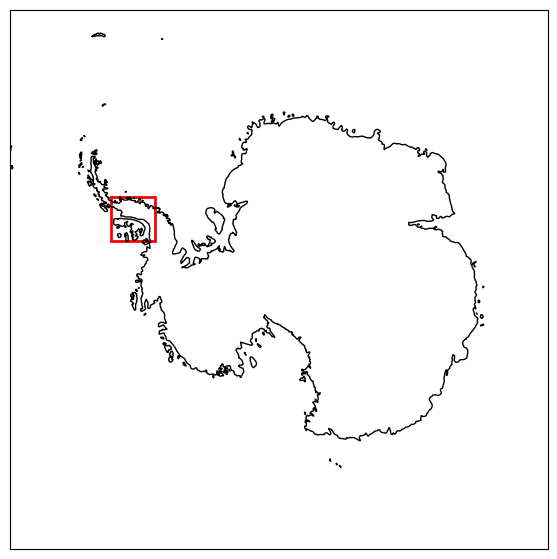

In [78]:
# Convert ROI center from meters to the appropriate scale and calculate half-width
cx, cy = ROI_CENTER_XY_M
half = ROI_HALF_WIDTH_CELLS * 100 

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -58], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_patch(Rectangle((cx - half, cy - half), 2 * half, 2 * half, fill=False, edgecolor="red", linewidth=2, transform=ax.projection))
plt.show()


In [ ]:
cube_paths = [
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icetemp.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/sec.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/antarctica-combined.zarr",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/icemask_composite.zarr/",
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/antarctica_cube/ice_velocity.zarr",
]

ds = xr.open_mfdataset(cube_paths, engine="zarr", chunks={}, compat="no_conflicts")

x_index = int(np.abs(ds["x"].values - ROI_CENTER_XY_M[0]).argmin())
y_index = int(np.abs(ds["y"].values - ROI_CENTER_XY_M[1]).argmin())
x_slice = slice(x_index - ROI_HALF_WIDTH_CELLS, x_index + ROI_HALF_WIDTH_CELLS + 1)
y_slice = slice(y_index - ROI_HALF_WIDTH_CELLS, y_index + ROI_HALF_WIDTH_CELLS + 1)

ds = ds.isel(x=x_slice, y=y_slice).chunk({"x": -1, "y": -1})

ds


In [61]:
# !jupyter nbconvert --to script "your_notebook.ipynb"

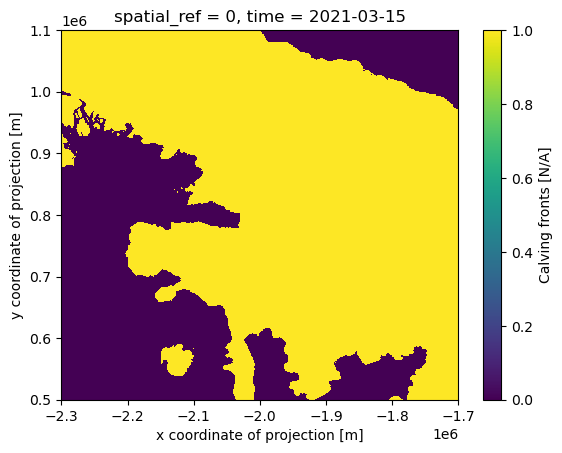

In [62]:
ds.calving_fronts.isel(time=-10).plot()

In [63]:
bbox = [-110.956, -76.993, -95.108, -72.915]

In [64]:
catalog = pystac_client.open("https://earth-search.aws.element84.com/v1")
chunk={} # <-- use dask
res=100 # 100m resolution

query1 = catalog.search(
    collections=["sentinel-2-l2a"], datetime="2021-12-01/2021-12-31", limit=10,
    bbox=bbox, query={"eo:cloud_cover": {"lt": 10}}
)

items = list(query1.items())
len(items)

218

In [74]:
sen2_ds = stac_load(
    items,
    bands=("red", "green", "blue", 'scl'),
    resolution=100,
    bbox=bbox,
    chunks={},
    groupby="solar_day",
)

# get last 20 scenes
sen2_ds = sen2_ds.isel(time=slice(-20, None))
sen2_ds

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 4663, x: 5182, time: 20)
Coordinates:
  * y            (y) float64 37kB 1.899e+06 1.899e+06 ... 1.433e+06 1.433e+06
  * x            (x) float64 41kB 3.05e+05 3.05e+05 ... 8.23e+05 8.23e+05
  * time         (time) datetime64[ns] 160B 2021-12-05T13:44:59.060000 ... 20...
    spatial_ref  int32 4B 32713
Data variables:
    red          (time, y, x) uint16 967MB dask.array<chunksize=(1, 4663, 5182), meta=np.ndarray>
    green        (time, y, x) uint16 967MB dask.array<chunksize=(1, 4663, 5182), meta=np.ndarray>
    blue         (time, y, x) uint16 967MB dask.array<chunksize=(1, 4663, 5182), meta=np.ndarray>
    scl          (time, y, x) uint8 483MB dask.array<chunksize=(1, 4663, 5182), meta=np.ndarray>

In [75]:
bad_scl = [0, 1, 3, 8, 9, 10]
clear = ~sen2_ds["scl"].isin(bad_scl)

rgb = sen2_ds[["red", "green", "blue"]].where(clear)

rgb_median = rgb.median("time", skipna=True)

with ProgressBar():
    rgb_median.to_array("band").plot.imshow(
        x="x",
        y="y",
        rgb="band",
        vmin=0,
        vmax=4000,
        figsize=(10, 10),
    )

[##                                      ] | 7% Completed | 8.34 s ms


KeyboardInterrupt: 